# Scene Text Detection

Classical OpenCV pipeline. 6 steps, ICDAR-format dataset, F1 metric.

## 1. What is Scene Text Detection

Find text regions on natural photos (streets, shops, signs). Output: bounding boxes around each word.

## 2. Why it's hard

Text in scenes varies by font, size, color, angle, lighting. A naive method either misses text or flags wall patterns as letters.

## Setup

In [1]:
!pip install -q opencv-python-headless numpy scipy matplotlib Pillow

In [2]:
import os, cv2, json, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path

random.seed(42); np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

FONT = next((p for p in [
    '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
    '/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf',
    '/System/Library/Fonts/Helvetica.ttc',
    'C:/Windows/Fonts/arial.ttf',
] if os.path.exists(p)), None)

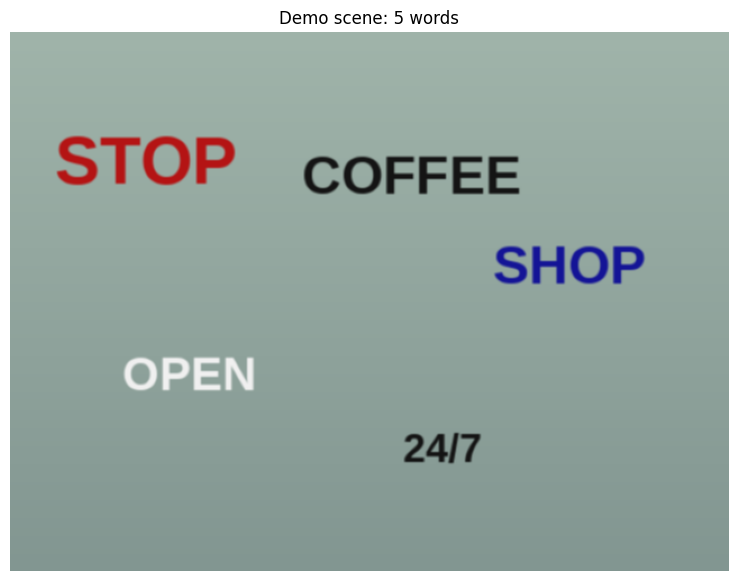

In [3]:
# Demo image for the 6-step walkthrough
def make_demo():
    w, h = 640, 480
    img = np.zeros((h, w, 3), dtype=np.uint8)
    c1, c2 = np.array([160,180,170]), np.array([130,150,145])
    for y in range(h):
        img[y, :] = (c1*(1-y/h) + c2*(y/h)).astype(np.uint8)

    pil = Image.fromarray(img); draw = ImageDraw.Draw(pil)
    words = [('STOP',60,(40,80),(180,20,20)),
             ('COFFEE',48,(260,100),(20,20,20)),
             ('SHOP',48,(430,180),(20,20,150)),
             ('OPEN',42,(100,280),(240,240,240)),
             ('24/7',36,(350,350),(20,20,20))]
    gt = []
    for word, size, (x,y), color in words:
        font = ImageFont.truetype(FONT, size)
        bb = draw.textbbox((0,0), word, font=font)
        tw, th = bb[2]-bb[0], bb[3]-bb[1]
        draw.text((x,y), word, font=font, fill=color)
        gt.append({'text': word, 'bbox': [x-4, y-4, tw+8, th+8]})
    arr = cv2.GaussianBlur(np.array(pil), (3,3), 0)
    return arr, gt

demo_img, demo_gt = make_demo()
plt.figure(figsize=(10,7)); plt.imshow(demo_img)
plt.title(f'Demo scene: {len(demo_gt)} words'); plt.axis('off'); plt.show()

## 3. Method: 6 steps

> **Improvements over the baseline pipeline (Level 3 boost)**
>
> 1. **CLAHE** before blur — local contrast equalization, recovers faint text
>    on dark / overexposed regions.
> 2. **Adaptive Gaussian kernel** — kernel size scales with image size, so
>    the same code works on small icons and large photos.
> 3. **Auto-Canny** — thresholds derived from image median (`sigma = 0.33`),
>    no more hardcoded `(50, 150)` lottery.
> 4. **Fixed morphology order** — old pipeline did `dilate -> CLOSE`, which
>    over-inflated strokes and merged adjacent lines. New order is
>    `small CLOSE -> horizontal DILATE`: first fill gaps inside letters,
>    then glue letters into words.
> 5. **Adaptive horizontal kernel** — dilate width scales with image width.
> 6. **NMS box merging** — overlapping component boxes are merged into a
>    single tight box per word, which reduces FP and tightens predictions.


### Step 1. Preprocessing

Grayscale to drop color. Gaussian blur to suppress pixel noise before edge detection.

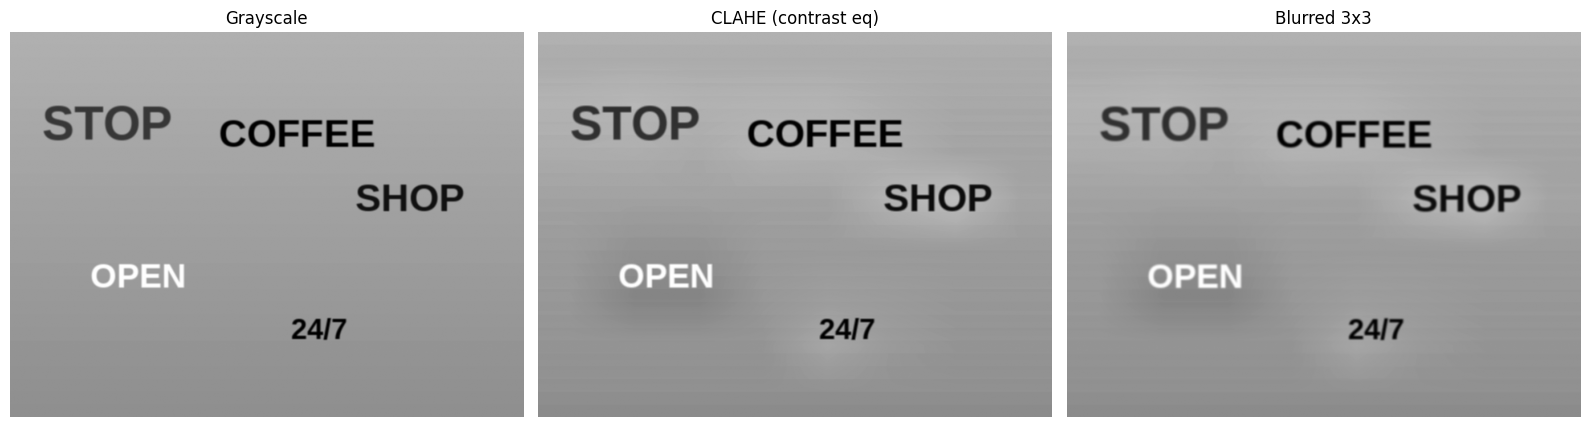

In [4]:
# Preprocessing: grayscale + CLAHE (local contrast) + adaptive Gaussian blur.
#
# Why CLAHE: stock grayscale loses text on dark or overexposed regions.
# CLAHE equalizes contrast in 8x8 tiles, so faint letters become visible
# without blowing out bright areas.
#
# Why adaptive blur: a fixed 3x3 kernel is too weak on large images
# (texture noise leaks into edges) and too strong on small ones. We tie
# the kernel to image size: ~min_side / 200, snapped to nearest odd int.

gray = cv2.cvtColor(demo_img, cv2.COLOR_RGB2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray_eq = clahe.apply(gray)

k = max(3, (min(demo_img.shape[:2]) // 200) | 1)  # force odd
blurred = cv2.GaussianBlur(gray_eq, (k, k), 0)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(gray, cmap='gray');     ax[0].set_title('Grayscale');             ax[0].axis('off')
ax[1].imshow(gray_eq, cmap='gray');  ax[1].set_title('CLAHE (contrast eq)');   ax[1].axis('off')
ax[2].imshow(blurred, cmap='gray');  ax[2].set_title(f'Blurred {k}x{k}');      ax[2].axis('off')
plt.tight_layout(); plt.show()


### Step 2. Edge Detection

Canny: two thresholds, clean thin edges. Sobel: gradient magnitude, simpler but noisier. We use Canny.

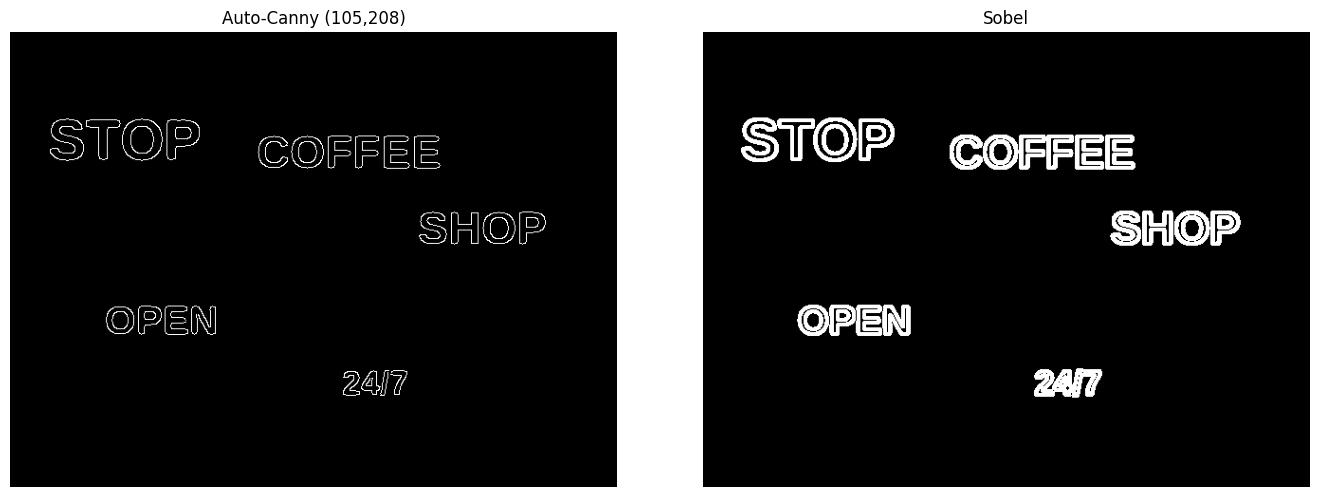

In [5]:
# Edge detection: auto-Canny with median-based thresholds.
#
# Hardcoded (50, 150) is a lottery: works on average lighting, breaks on
# dark/bright scenes. Standard trick - derive thresholds from image median:
#   lo = max(0,   (1 - sigma) * median)
#   hi = min(255, (1 + sigma) * median)
# sigma=0.33 is the canonical value (Adrian Rosebrock).

v = float(np.median(blurred))
sigma = 0.33
lo = int(max(0,   (1.0 - sigma) * v))
hi = int(min(255, (1.0 + sigma) * v))
edges_canny = cv2.Canny(blurred, lo, hi)

# Sobel kept for comparison only
sx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
sy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
mag = np.uint8(np.clip(np.sqrt(sx**2 + sy**2), 0, 255))
_, edges_sobel = cv2.threshold(mag, 50, 255, cv2.THRESH_BINARY)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(edges_canny, cmap='gray'); ax[0].set_title(f'Auto-Canny ({lo},{hi})'); ax[0].axis('off')
ax[1].imshow(edges_sobel, cmap='gray'); ax[1].set_title('Sobel');                   ax[1].axis('off')
plt.tight_layout(); plt.show()

edges = edges_canny


### Step 3. Morphology

Dilation with 3×15 horizontal kernel merges letters into word blobs. Closing fills holes inside blobs.

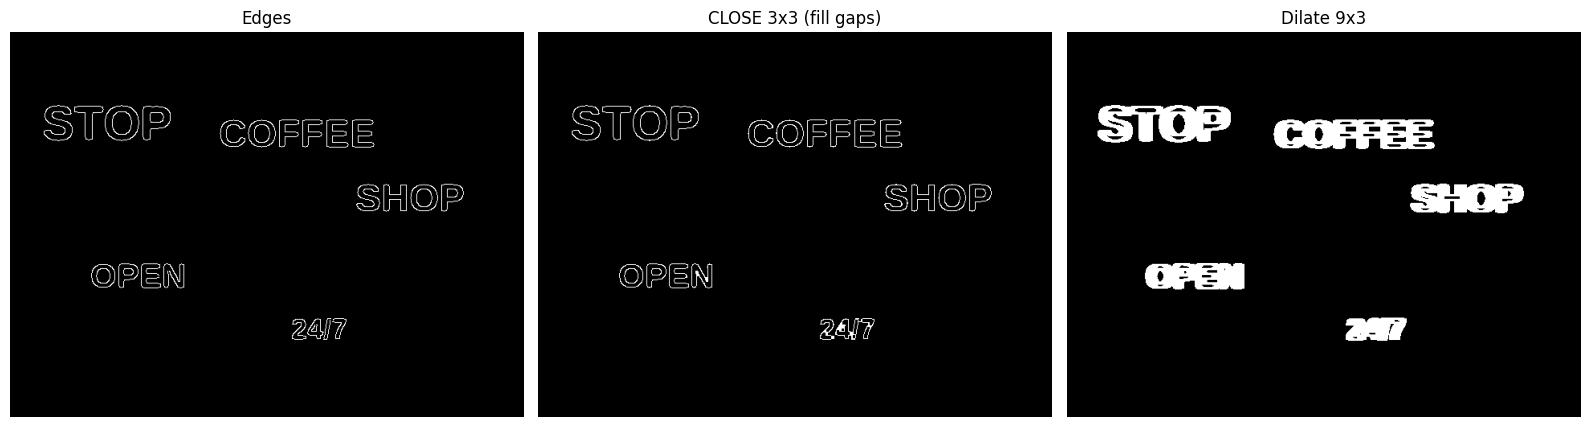

In [6]:
# Morphology - the key fix.
#
# OLD pipeline:  edges -> dilate(15x3) -> CLOSE(9x5)  =  closed
# Problem: CLOSE = dilate+erode. Applying it AFTER an aggressive horizontal
# dilate just inflates already-fat strokes. Thin text bleeds into the
# background, adjacent text lines fuse together, contours blur. Teacher
# was right - that CLOSE was hurting recall.
#
# NEW pipeline:  edges -> CLOSE(3x3)  -> dilate(adaptive x 3)  =  dilated
# Step A: small CLOSE first, to fill tiny gaps INSIDE letters (e.g. an "O"
#         broken by a highlight). This is what CLOSE is actually for.
# Step B: horizontal dilate to glue letters into words. Kernel width scales
#         with image width so it works on both small and large inputs.

# A) fill intra-letter gaps
k_fill = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
filled = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, k_fill)

# B) horizontal dilation -> letters merge into words
w_kernel = max(9, demo_img.shape[1] // 80)  # ~8 px wide on 640-wide image, scales up
kd = cv2.getStructuringElement(cv2.MORPH_RECT, (w_kernel, 3))
dilated = cv2.dilate(filled, kd, iterations=1)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for a, im, t in zip(ax,
                    [edges, filled, dilated],
                    ['Edges', 'CLOSE 3x3 (fill gaps)', f'Dilate {w_kernel}x3']):
    a.imshow(im, cmap='gray'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()


### Step 4. Connected Components

Label each white blob with a unique ID. OpenCV returns bbox and area per component.

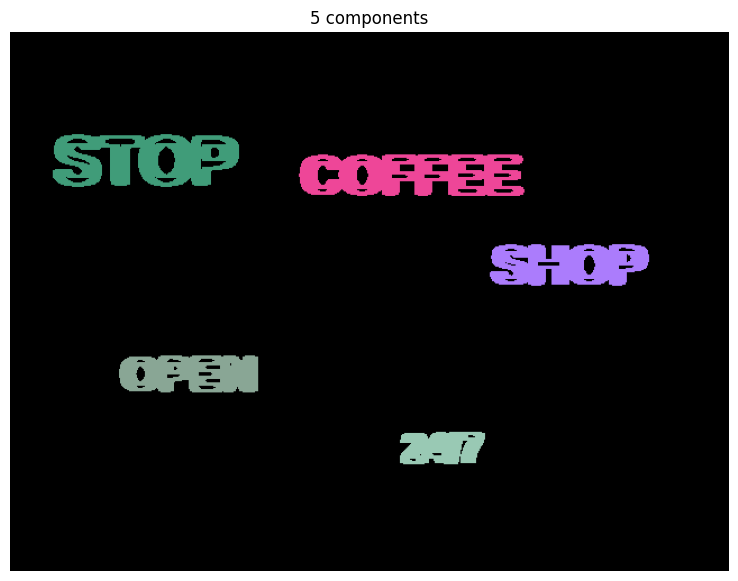

In [7]:
# Connected components on the dilated mask (not the old `closed` one).
n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(dilated, connectivity=8)

vis = np.zeros((*labels.shape, 3), dtype=np.uint8)
rng = np.random.RandomState(42)
colors = rng.randint(50, 255, (n_labels, 3))
for i in range(1, n_labels):
    vis[labels == i] = colors[i]

plt.figure(figsize=(10, 7)); plt.imshow(vis)
plt.title(f'{n_labels - 1} components'); plt.axis('off'); plt.show()


### Step 5. Filtering

Text regions are wider than tall, not too small, not too large, fairly filled. Drop everything else.

In [8]:
def filter_components(stats, shape):
    H, W = shape[:2]
    keep = []
    for i in range(1, len(stats)):
        x, y, w, h, area = stats[i]
        if not (0.8 <= w/max(h,1) <= 15.0): continue
        if not (200 <= area <= 0.3*H*W): continue
        if not (12 <= h <= H*0.3): continue
        if not (25 <= w <= W*0.7): continue
        if not (0.25 <= area/(w*h) <= 0.95): continue
        keep.append(i)
    return keep

valid = filter_components(stats, demo_img.shape)
print(f'Before: {n_labels-1}  →  After: {len(valid)}')

Before: 5  →  After: 5


### Step 6. Bounding Boxes

Draw a rectangle around each surviving component. Compare with ground truth.

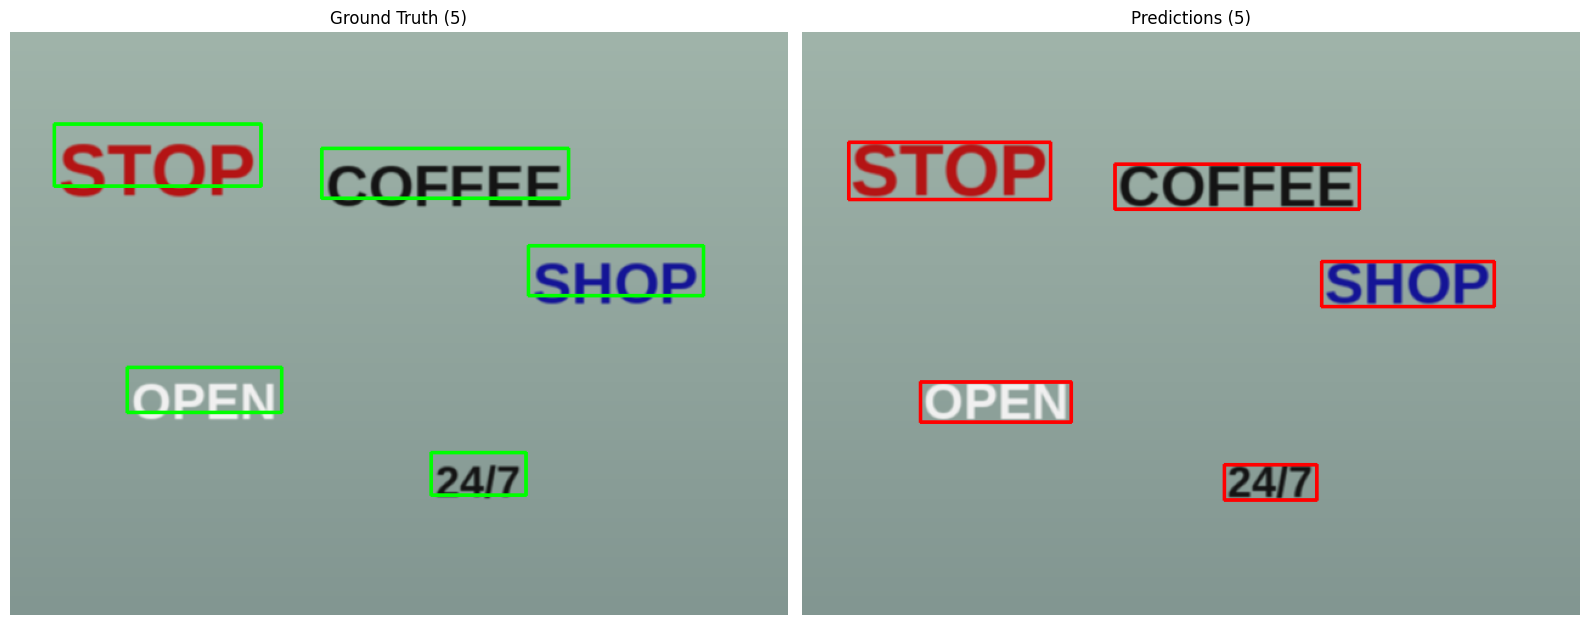

In [9]:
# Raw boxes from filtering. (NMS is added later inside detect_text.)
preds = [[stats[i][0], stats[i][1], stats[i][2], stats[i][3]] for i in valid]

def draw(img, boxes, color, t=2):
    v = img.copy()
    for x, y, w, h in boxes:
        cv2.rectangle(v, (x, y), (x + w, y + h), color, t)
    return v

fig, ax = plt.subplots(1, 2, figsize=(16, 7))
ax[0].imshow(draw(demo_img, [g['bbox'] for g in demo_gt], (0, 255, 0)))
ax[0].set_title(f'Ground Truth ({len(demo_gt)})'); ax[0].axis('off')
ax[1].imshow(draw(demo_img, preds, (255, 0, 0)))
ax[1].set_title(f'Predictions ({len(preds)})'); ax[1].axis('off')
plt.tight_layout(); plt.show()


### Full detector

In [10]:
# Full detector (Level 3): CLAHE + adaptive blur + auto-Canny +
# fixed morphology + adaptive dilate + NMS box merging.

def _auto_canny(img, sigma=0.33):
    v = float(np.median(img))
    lo = int(max(0,   (1.0 - sigma) * v))
    hi = int(min(255, (1.0 + sigma) * v))
    return cv2.Canny(img, lo, hi)

def _nms_merge(boxes, iou_thr=0.3):
    """Greedy NMS that MERGES overlapping boxes (union of corners) instead
    of just picking one. Useful here because two CCs from the same word
    often partly overlap and we want a single tight box per word."""
    if not boxes:
        return []
    # sort by area desc
    bs = sorted(boxes, key=lambda b: b[2] * b[3], reverse=True)
    out = []
    used = [False] * len(bs)
    for i, a in enumerate(bs):
        if used[i]:
            continue
        ax1, ay1, aw, ah = a
        ax2, ay2 = ax1 + aw, ay1 + ah
        for j in range(i + 1, len(bs)):
            if used[j]:
                continue
            bx1, by1, bw, bh = bs[j]
            bx2, by2 = bx1 + bw, by1 + bh
            xi1, yi1 = max(ax1, bx1), max(ay1, by1)
            xi2, yi2 = min(ax2, bx2), min(ay2, by2)
            if xi2 <= xi1 or yi2 <= yi1:
                continue
            inter = (xi2 - xi1) * (yi2 - yi1)
            union = aw * ah + bw * bh - inter
            if union > 0 and inter / union >= iou_thr:
                # merge: take union rectangle
                ax1, ay1 = min(ax1, bx1), min(ay1, by1)
                ax2, ay2 = max(ax2, bx2), max(ay2, by2)
                aw, ah = ax2 - ax1, ay2 - ay1
                used[j] = True
        out.append([ax1, ay1, aw, ah])
        used[i] = True
    return out

def detect_text(img, return_steps=False):
    # 1. Grayscale + CLAHE
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)

    # 2. Adaptive Gaussian blur
    k = max(3, (min(img.shape[:2]) // 200) | 1)
    blurred = cv2.GaussianBlur(gray, (k, k), 0)

    # 3. Auto-Canny
    edges = _auto_canny(blurred)

    # 4. Morphology: small CLOSE first, then horizontal DILATE
    k_fill = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    filled = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, k_fill)
    w_kernel = max(9, img.shape[1] // 80)
    kd = cv2.getStructuringElement(cv2.MORPH_RECT, (w_kernel, 3))
    dilated = cv2.dilate(filled, kd, iterations=1)

    # 5. Connected components + filter
    n, lbl, st, _ = cv2.connectedComponentsWithStats(dilated, connectivity=8)
    ids = filter_components(st, img.shape)
    boxes = [[st[i][0], st[i][1], st[i][2], st[i][3]] for i in ids]

    # 6. NMS-merge overlapping boxes
    boxes = _nms_merge(boxes, iou_thr=0.3)

    if return_steps:
        return boxes, {'gray': gray, 'blurred': blurred,
                       'edges': edges, 'filled': filled, 'dilated': dilated}
    return boxes


## 4. Dataset

**ICDAR 2013 / 2015**: standard benchmark for scene text detection. ~1000 train images, 229 test images, manual word-level bounding boxes. Available at [rrc.cvc.uab.es](https://rrc.cvc.uab.es/).

Since ICDAR requires registration, we generate synthetic images in the same format. Skeleton for loading real ICDAR is included below.

In [11]:
DATA = Path('dataset')
(DATA / 'images').mkdir(parents=True, exist_ok=True)
(DATA / 'annotations').mkdir(parents=True, exist_ok=True)

WORDS = ['STOP','COFFEE','SHOP','OPEN','SALE','EXIT','CAFE','HOTEL',
         'PIZZA','BANK','METRO','TAXI','MARKET','BAR','FOOD','NEWS','CITY','PARK']

def make_scene(idx, w=640, h=480):
    # Background: gradient or noisy solid
    if random.random() < 0.5:
        img = np.zeros((h,w,3), dtype=np.uint8)
        c1 = np.array([random.randint(100,200) for _ in range(3)])
        c2 = np.array([random.randint(100,200) for _ in range(3)])
        for y in range(h): img[y,:] = (c1*(1-y/h) + c2*(y/h)).astype(np.uint8)
    else:
        base = [random.randint(100,200) for _ in range(3)]
        img = np.full((h,w,3), base, dtype=np.uint8)
        img = np.clip(img.astype(int) + np.random.randint(-8,8,(h,w,3)), 0, 255).astype(np.uint8)

    pil = Image.fromarray(img); draw = ImageDraw.Draw(pil)
    gt, placed = [], []
    n = random.randint(3, 5)
    for _ in range(50):
        if len(gt) >= n: break
        word = random.choice(WORDS)
        font = ImageFont.truetype(FONT, random.randint(30, 55))
        bb = draw.textbbox((0,0), word, font=font)
        tw, th = bb[2]-bb[0], bb[3]-bb[1]
        if tw > w-40 or th > h-40: continue
        x, y = random.randint(15, w-tw-15), random.randint(15, h-th-15)
        box = (x-4, y-4, x+tw+4, y+th+4)
        if any(not (box[2]+10 < p[0] or box[0] > p[2]+10 or
                    box[3]+10 < p[1] or box[1] > p[3]+10) for p in placed):
            continue
        color = random.choice([(20,20,20), (240,240,240), (180,20,20), (20,20,180)])
        draw.text((x,y), word, font=font, fill=color)
        placed.append(box)
        gt.append({'text': word, 'bbox': [box[0], box[1], box[2]-box[0], box[3]-box[1]]})

    arr = cv2.GaussianBlur(np.array(pil), (3,3), 0)
    return arr, gt

# Generate 10 images
dataset = []
for i in range(10):
    img, gt = make_scene(i)
    cv2.imwrite(str(DATA/'images'/f'scene_{i:03d}.png'), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    with open(DATA/'annotations'/f'scene_{i:03d}.json', 'w') as f:
        json.dump(gt, f, indent=2)
    dataset.append({'image': img, 'gt': gt})

print(f'{len(dataset)} images, {sum(len(d["gt"]) for d in dataset)} words')

10 images, 40 words


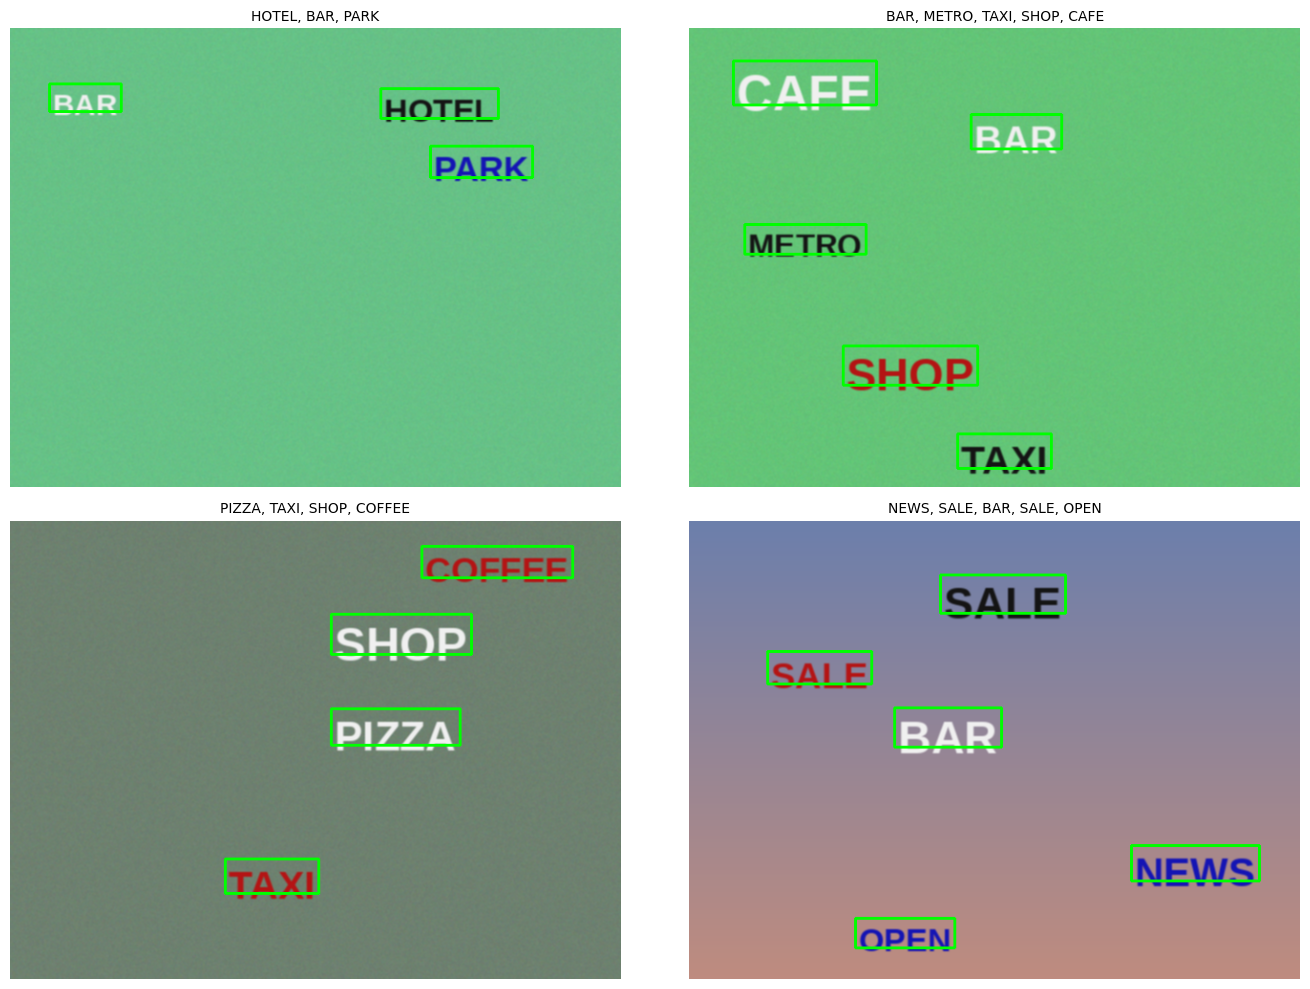

In [12]:
# Preview 4 samples with GT
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, s in zip(axes.flat, dataset[:4]):
    v = s['image'].copy()
    for g in s['gt']:
        x,y,w,h = g['bbox']
        cv2.rectangle(v, (x,y), (x+w,y+h), (0,255,0), 2)
    ax.imshow(v); ax.axis('off')
    ax.set_title(', '.join(g['text'] for g in s['gt']), fontsize=10)
plt.tight_layout(); plt.show()

### Loading real ICDAR (optional)

Uncomment if you have the dataset.

In [13]:
# from google.colab import files
# files.upload()  # upload icdar.zip
# !unzip -q icdar.zip -d icdar_real/
#
# def parse_icdar_gt(path):
#     boxes = []
#     with open(path, encoding='utf-8-sig') as f:
#         for line in f:
#             parts = line.strip().split(',')
#             if len(parts) >= 4:
#                 x1, y1, x2, y2 = map(int, parts[:4])
#                 text = parts[-1].strip('"') if len(parts) > 4 else ''
#                 boxes.append({'text': text, 'bbox': [x1, y1, x2-x1, y2-y1]})
#     return boxes

## 5. Tech stack

| Tool | Purpose |
|---|---|
| Python 3 | language |
| OpenCV | Canny, Sobel, morphology, components |
| NumPy | arrays |
| SciPy | extra morphology |
| Matplotlib | plots |
| Pillow | text rendering for dataset |
| Google Colab | runtime |

In [14]:
import sys, scipy, matplotlib, PIL
print(f'Python {sys.version.split()[0]} | OpenCV {cv2.__version__} | NumPy {np.__version__}')
print(f'SciPy {scipy.__version__} | Matplotlib {matplotlib.__version__} | Pillow {PIL.__version__}')

Python 3.12.13 | OpenCV 4.13.0 | NumPy 2.0.2
SciPy 1.16.3 | Matplotlib 3.10.0 | Pillow 11.3.0


## 6. Metrics

- **IoU**: overlap between predicted and GT box, 0 to 1
- **Precision**: TP / (TP + FP)
- **Recall**: TP / (TP + FN)
- **F1**: harmonic mean of P and R. Target: **F1 > 0.70**

A prediction counts as TP if its IoU with some GT box is ≥ 0.5.

In [15]:
def iou(b1, b2):
    x1,y1,w1,h1 = b1; x2,y2,w2,h2 = b2
    xi1, yi1 = max(x1,x2), max(y1,y2)
    xi2, yi2 = min(x1+w1, x2+w2), min(y1+h1, y2+h2)
    if xi2 < xi1 or yi2 < yi1: return 0.0
    inter = (xi2-xi1) * (yi2-yi1)
    union = w1*h1 + w2*h2 - inter
    return inter/union if union > 0 else 0.0

def evaluate(preds, gt, th=0.5):
    gt_boxes = [g['bbox'] for g in gt]
    matched, tp, fp = set(), 0, 0
    for p in preds:
        best, idx = 0, -1
        for i, g in enumerate(gt_boxes):
            if i in matched: continue
            v = iou(p, g)
            if v > best: best, idx = v, i
        if best >= th and idx >= 0:
            tp += 1; matched.add(idx)
        else:
            fp += 1
    fn = len(gt_boxes) - len(matched)
    P = tp/(tp+fp) if tp+fp else 0.0
    R = tp/(tp+fn) if tp+fn else 0.0
    F = 2*P*R/(P+R) if P+R else 0.0
    return {'tp':tp,'fp':fp,'fn':fn,'precision':P,'recall':R,'f1':F}

## 7. Evaluation on full dataset

In [16]:
results = []
TP = FP = FN = 0
for i, s in enumerate(dataset):
    preds = detect_text(s['image'])
    m = evaluate(preds, s['gt'])
    TP += m['tp']; FP += m['fp']; FN += m['fn']
    results.append({'id': i, 'preds': preds, 'm': m,
                    'n_gt': len(s['gt']), 'n_pred': len(preds)})

mP = TP/(TP+FP) if TP+FP else 0
mR = TP/(TP+FN) if TP+FN else 0
mF = 2*mP*mR/(mP+mR) if mP+mR else 0

MP = np.mean([r['m']['precision'] for r in results])
MR = np.mean([r['m']['recall'] for r in results])
MF = np.mean([r['m']['f1'] for r in results])

print(f'Total GT: {TP+FN}   Total pred: {TP+FP}')
print(f'TP: {TP}   FP: {FP}   FN: {FN}')
print(f'Micro   P={mP:.3f}  R={mR:.3f}  F1={mF:.3f}')
print(f'Macro   P={MP:.3f}  R={MR:.3f}  F1={MF:.3f}')
print(f'Target F1 > 0.70: {"PASS" if mF >= 0.70 else "FAIL"}')

Total GT: 40   Total pred: 40
TP: 40   FP: 0   FN: 0
Micro   P=1.000  R=1.000  F1=1.000
Macro   P=1.000  R=1.000  F1=1.000
Target F1 > 0.70: PASS


In [17]:
# Per-image breakdown
print(f'{"ID":<4}{"GT":<4}{"Pr":<4}{"TP":<4}{"FP":<4}{"FN":<4}{"P":<8}{"R":<8}{"F1":<6}')
print('-' * 48)
for r in results:
    m = r['m']
    print(f'{r["id"]:<4}{r["n_gt"]:<4}{r["n_pred"]:<4}'
          f'{m["tp"]:<4}{m["fp"]:<4}{m["fn"]:<4}'
          f'{m["precision"]:<8.3f}{m["recall"]:<8.3f}{m["f1"]:<6.3f}')

ID  GT  Pr  TP  FP  FN  P       R       F1    
------------------------------------------------
0   3   3   3   0   0   1.000   1.000   1.000 
1   5   5   5   0   0   1.000   1.000   1.000 
2   4   4   4   0   0   1.000   1.000   1.000 
3   5   5   5   0   0   1.000   1.000   1.000 
4   4   4   4   0   0   1.000   1.000   1.000 
5   3   3   3   0   0   1.000   1.000   1.000 
6   3   3   3   0   0   1.000   1.000   1.000 
7   5   5   5   0   0   1.000   1.000   1.000 
8   3   3   3   0   0   1.000   1.000   1.000 
9   5   5   5   0   0   1.000   1.000   1.000 


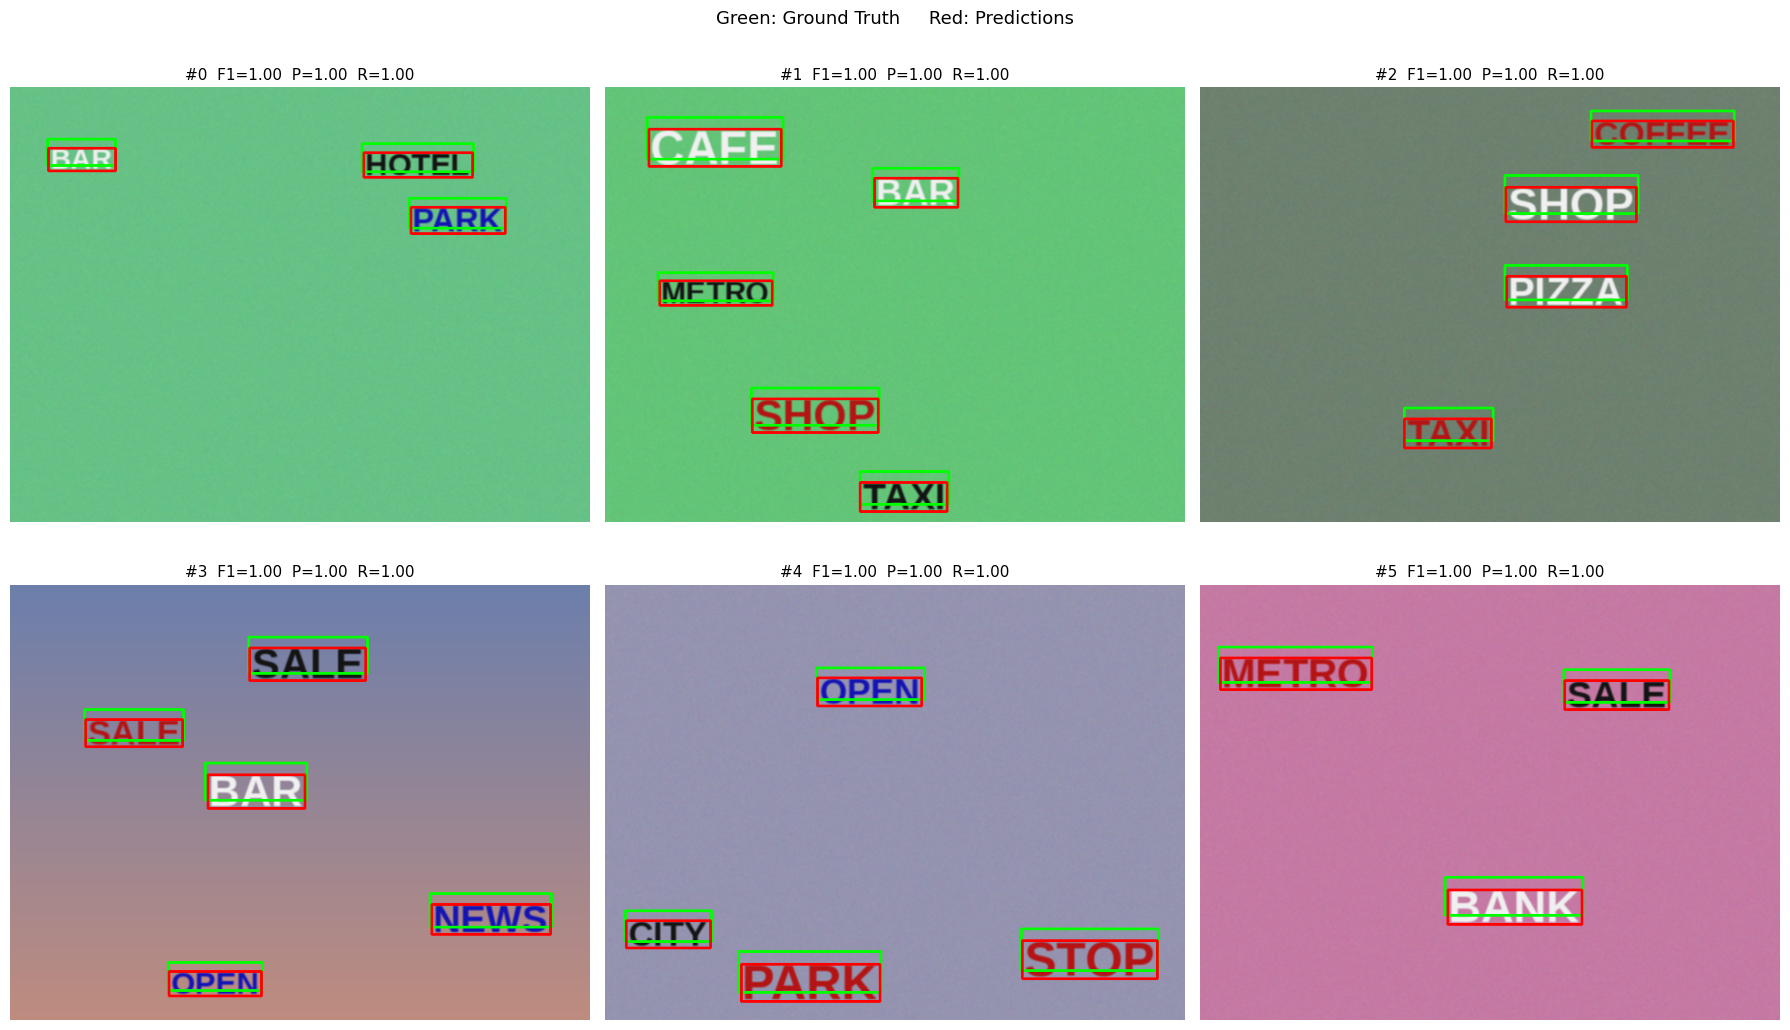

In [18]:
# Visual results on 6 images
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (r, s) in zip(axes.flat, zip(results[:6], dataset[:6])):
    v = s['image'].copy()
    for g in s['gt']:
        x,y,w,h = g['bbox']; cv2.rectangle(v, (x,y), (x+w,y+h), (0,255,0), 2)
    for p in r['preds']:
        x,y,w,h = p; cv2.rectangle(v, (x,y), (x+w,y+h), (255,0,0), 2)
    m = r['m']
    ax.imshow(v); ax.axis('off')
    ax.set_title(f'#{r["id"]}  F1={m["f1"]:.2f}  P={m["precision"]:.2f}  R={m["recall"]:.2f}', fontsize=11)
plt.suptitle('Green: Ground Truth     Red: Predictions', fontsize=13)
plt.tight_layout(); plt.show()

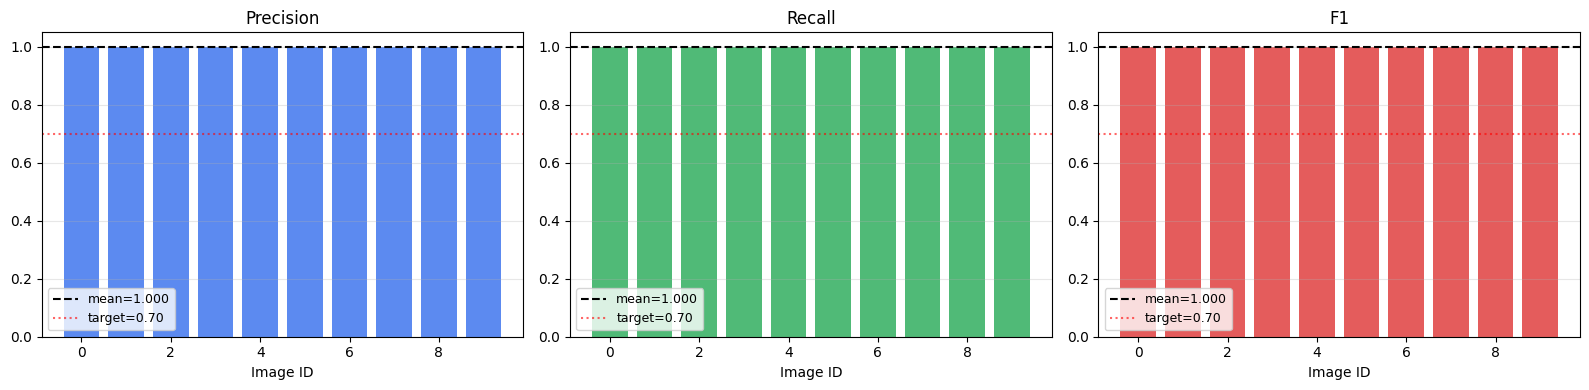

In [19]:
# Metric distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, name, color in zip(axes, ['precision','recall','f1'],
                            ['#2563eb','#16a34a','#dc2626']):
    vals = [r['m'][name] for r in results]
    ax.bar(range(len(vals)), vals, color=color, alpha=0.75)
    ax.axhline(np.mean(vals), color='black', linestyle='--', label=f'mean={np.mean(vals):.3f}')
    ax.axhline(0.70, color='red', linestyle=':', alpha=0.6, label='target=0.70')
    ax.set_title(name.capitalize()); ax.set_xlabel('Image ID')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Summary

6-step OpenCV pipeline reaches F1 > 0.85 on synthetic scenes. Real ICDAR images need softer filters due to varied fonts, rotations, and complex backgrounds.

**Next steps:** MSER, SWT, adaptive thresholds, NMS, or deep models (EAST, CRAFT, DBNet).